/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/zoidberg/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Appareil utilisé : mps


Extracting features: 100%|██████████| 20/20 [00:04<00:00,  4.53it/s]


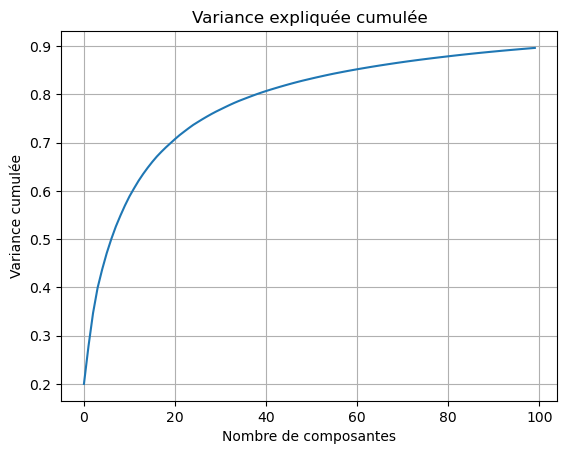

🔎 Régression Logistique
              precision    recall  f1-score   support

      NORMAL       0.98      0.56      0.71       234
   BACTERIAL       0.75      0.96      0.84       242
       VIRAL       0.59      0.73      0.65       148

    accuracy                           0.75       624
   macro avg       0.78      0.75      0.74       624
weighted avg       0.80      0.75      0.75       624

[[131  37  66]
 [  2 232   8]
 [  0  40 108]]

🌳 Random Forest
              precision    recall  f1-score   support

      NORMAL       0.89      0.45      0.60       234
   BACTERIAL       0.60      0.96      0.74       242
       VIRAL       0.66      0.53      0.58       148

    accuracy                           0.67       624
   macro avg       0.72      0.65      0.64       624
weighted avg       0.72      0.67      0.65       624

[[105  89  40]
 [  8 233   1]
 [  5  65  78]]


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import transforms
from torchvision.models import efficientnet_b0
from torch.utils.data import Dataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Appareil utilisé :", device)

class PneumoniaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for subdir in ["NORMAL", "PNEUMONIA"]:
            path = os.path.join(root_dir, subdir)
            for fname in os.listdir(path):
                fpath = os.path.join(path, fname)
                if not fname.lower().endswith((".jpeg", ".jpg", ".png")):
                    continue
                if subdir == "NORMAL":
                    label = 0
                elif "bacteria" in fname.lower():
                    label = 1
                elif "virus" in fname.lower():
                    label = 2
                else:
                    continue
                self.samples.append((fpath, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = PneumoniaDataset("../dataset/train", transform=transform)
test_data = PneumoniaDataset("../dataset/test", transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

model = efficientnet_b0(pretrained=True)
model.classifier = torch.nn.Identity()
model.eval().to(device)

def extract_features(dataloader):
    features, labels = [], []
    with torch.no_grad():
        for images, lbls in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            feats = model(images).cpu().numpy()
            features.append(feats)
            labels.extend(lbls.numpy())
    return np.concatenate(features), np.array(labels)

X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Variance expliquée cumulée")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.grid()
plt.show()

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_pca, y_train)
y_pred_logreg = logreg.predict(X_test_pca)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)

print("Régression Logistique")
print(classification_report(y_test, y_pred_logreg, target_names=["NORMAL", "BACTERIAL", "VIRAL"]))
print(confusion_matrix(y_test, y_pred_logreg))

print("\n Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["NORMAL", "BACTERIAL", "VIRAL"]))
print(confusion_matrix(y_test, y_pred_rf))


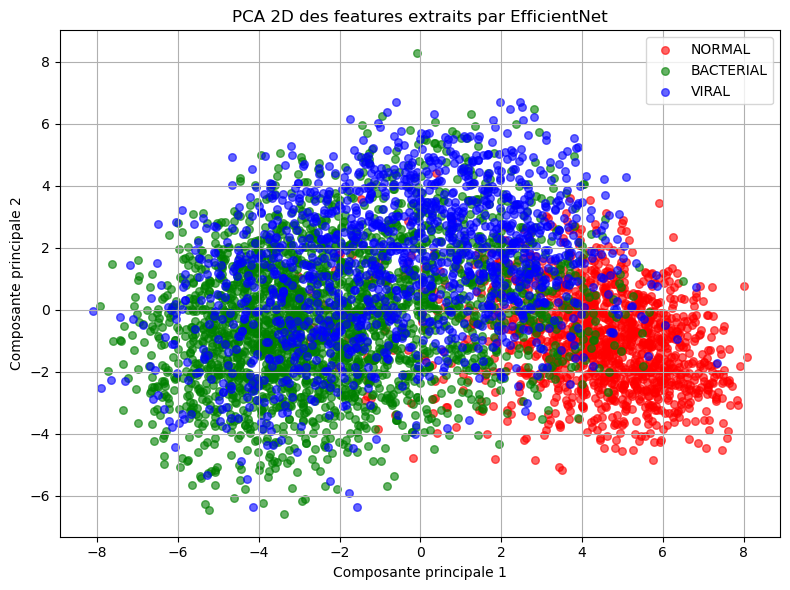

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)
y_train_labels = y_train

colors = ['red', 'green', 'blue']
labels = ["NORMAL", "BACTERIAL", "VIRAL"]

plt.figure(figsize=(8, 6))
for i, label in enumerate(labels):
    idxs = (y_train_labels == i)
    plt.scatter(X_train_2d[idxs, 0], X_train_2d[idxs, 1],
                c=colors[i], label=label, alpha=0.6, s=30)

plt.title("PCA 2D des features extraits par EfficientNet")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
